<a href="https://colab.research.google.com/github/diegoax/ALNAE-2026/blob/main/Notebooks/clase13_ALNAE_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clase 13 (Viernes 22 de mayo, 2026)
---

Vamos a utilizar la **SVD** para comprimir o aproximar una imagen. Matemáticamente, una imagen en escala de grises se puede representar como una matriz $A$ de dimensiones $m \times n$, cuyas entradas son valores reales en [0,1], donde 1 significa que ese pixel es blanco y 0 que es negro, y en el medio los valores de grises intermedios.

Tenemos la descomposición
$$A = U \Sigma V^T,$$

Donde:
*   **$U$**: Es una matriz de $m \times m$
*   **$\Sigma$**: Es una matriz diagonal de $m \times n$ con los valores singulares $\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r > 0$ en la diagonal, donde $r$ es el rango de la matriz.
*   **$V^T$**: Es la transpuesta de una matriz de $n \times n$

### Representación como suma de matrices de rango 1
La igualdad anterior se puede escribir como una suma de productos exteriores:

$$A = \sum_{i=1}^{r} \sigma_i \mathbf{u}_i \mathbf{v}_i^T$$

Cada término $\sigma_i \mathbf{u}_i \mathbf{v}_i^T$ es una matriz de rango 1 que aporta una capa de información a la imagen final.

### Aproximación de Bajo Rango (Teorema de Eckart-Young)
Si queremos aproximar la imagen original usando solo los primeros $k$ componentes (donde $k < r$), obtenemos la matriz $A_k$:

$$
A_k = \sum_{i=1}^{k} \sigma_i \mathbf{u}_i \mathbf{v}_i^T
\tag{1}
$$

$A_k$ es la mejor aproximación posible de rango $k$ para la matriz $A$ (en el sentido de la norma operador, ver clase anterior). En el código, esto es lo que hacemos al variar los `indices` para ver cómo la imagen de la cebra recupera nitidez a medida que aumentamos el valor de $k$.

In [ ]:
install.packages("png")

In [ ]:
url <- "https://i.imgur.com/pvyHJE7.png"
download.file(url, "cebra.png", mode = "wb")
imagen <- png::readPNG("/content/cebra.png")
imagen <- imagen[,,1]

library(magrittr)
library(ggplot2)
library(data.table)
theme_set(theme_bw())

h <- nrow(imagen)
w <- ncol(imagen)

print(c(h,w))

[1] 674 720


La imagen es de dimensión 674 x 720, suponiendo razonablemnte que es de rango completo, la imagen original tendría rango 674.

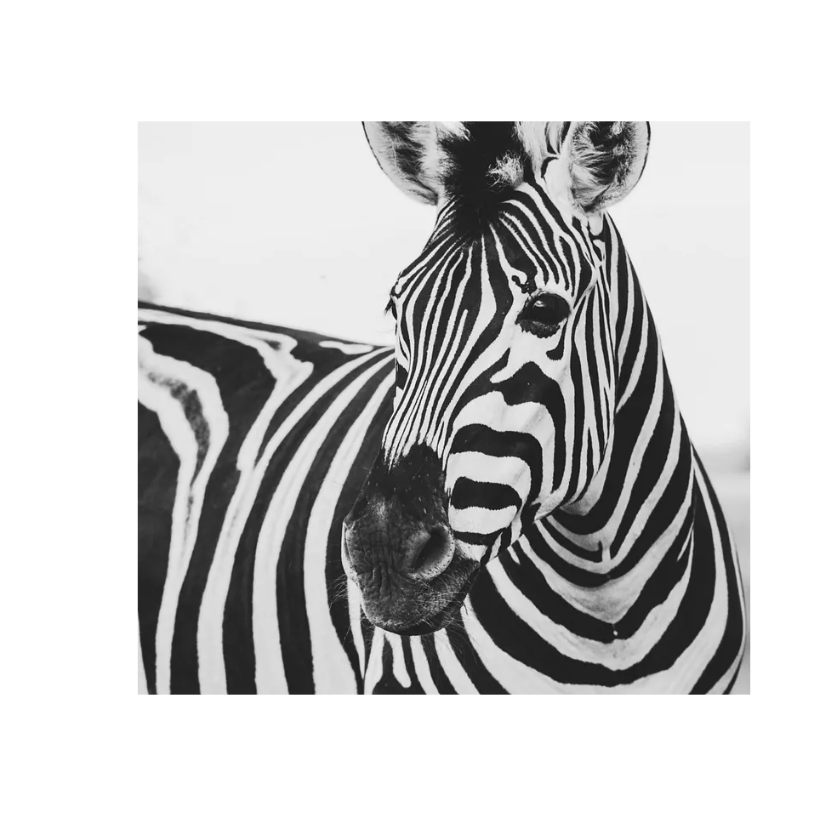

In [ ]:
plot(NA, xlim=c(0, 1), ylim=c(0,1), type="n", asp = h/w,
     xaxt="n", yaxt="n", xlab="", ylab="", bty="n")
rasterImage(imagen, xleft=0, ybottom=0, xright=1, ytop=1)

En el objeto `imagenes` se va a guardar una lista con las imágenes que se obtienen según la ecuación (1), cuando $k$ varía en el conjunto `indices`

In [ ]:
SVD <- svd(imagen)

U <- SVD$u
D <- SVD$d
V <- SVD$v

lista <- sapply(1:200, \(i) tcrossprod(U[,i], V[,i]), simplify = F)

indices <- c(1:4, 15, 50, 100, 150, 200)

# indices <- c(1:4,6,7)

imagenes <- sapply(indices, \(i) {
  img <- mapply("*", lista[1:i], D[1:i], SIMPLIFY = F) %>%
    Reduce("+", .)
  img[img < 0] <- 0
  img[img > 1] <- 1
  return(img)
  }, simplify = F)


null device 
          1

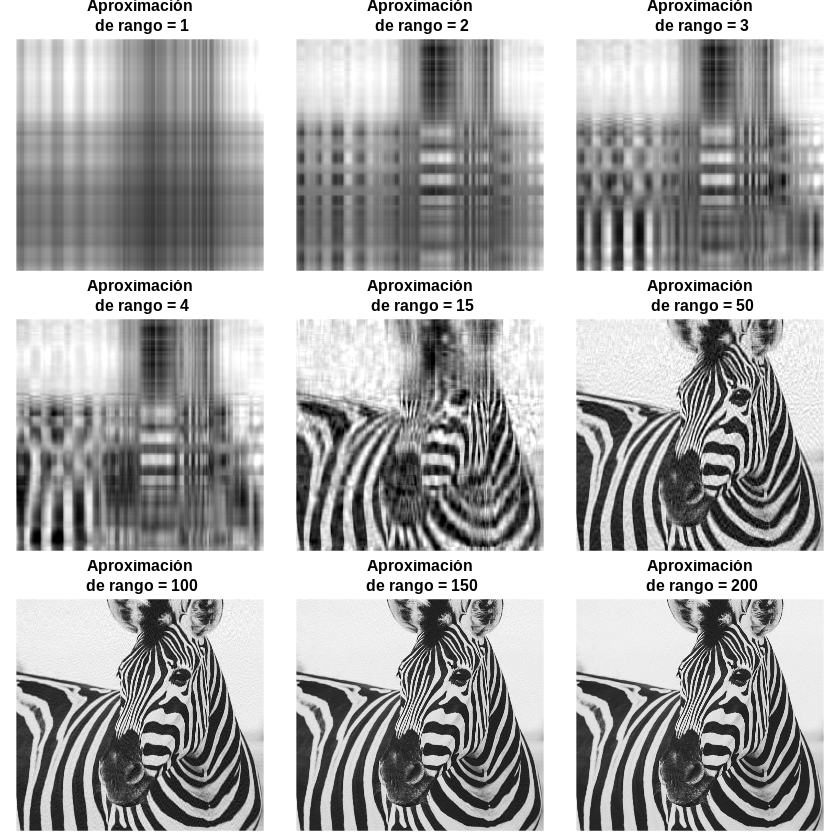

In [ ]:
par(mfrow = c(3,3), mai = c(0,0,0.25,0))
sapply(1:length(indices), \(i) {
  plot(NA, xlim=c(0, 1), ylim=c(0,1), type="n", asp = h/w,
       xaxt="n", yaxt="n", xlab="", ylab="", bty="n", main = sprintf("Aproximación\n de rango = %s",indices[i]))
  rasterImage(imagenes[[i]], xleft=0, ybottom=0, xright=1, ytop=1)
}) %>%
  invisible

dev.off()


### Análisis de Columnas Específicas

Para entender mejor cómo la SVD captura la información, vamos a seleccionar algunas columnas de la imagen (por ejemplo, las columnas 1, 2, 19, 400 y 710) y graficar sus valores de intensidad.

Ahí vamos a ver cómo varía el brillo a lo largo de ciertas columnas elegidas de la imagen. Se puede ver que en la imagen de rango 1, todas las columnas son colineales, (salvo el truncamiento que se produce en la columna 710) y a medida que se aumenta el rango, las columnas se van independizando linealmente.

### Rango 1

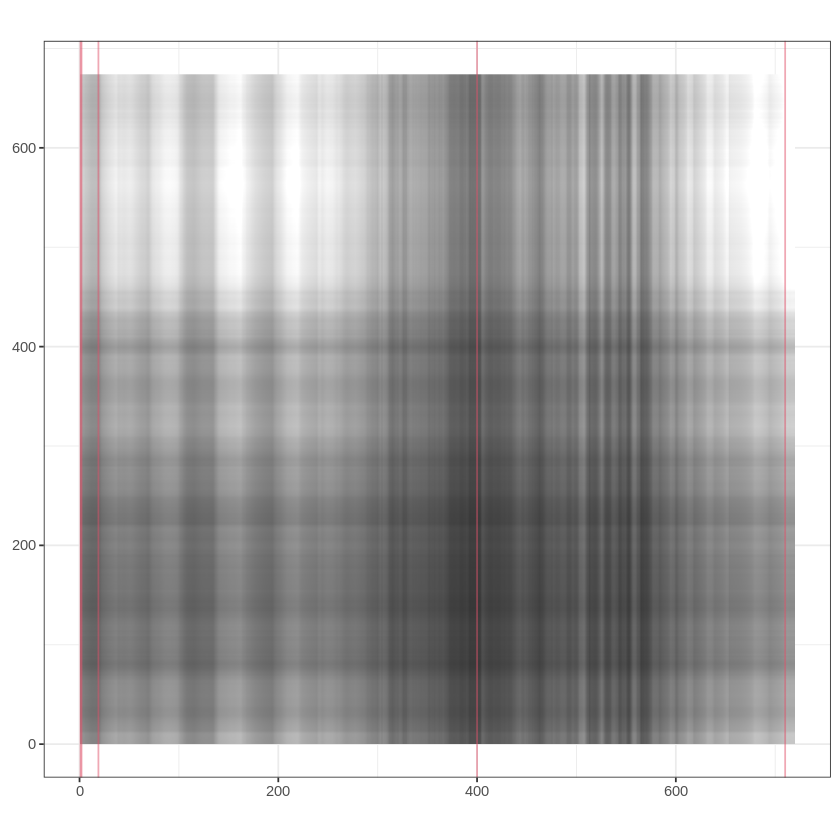

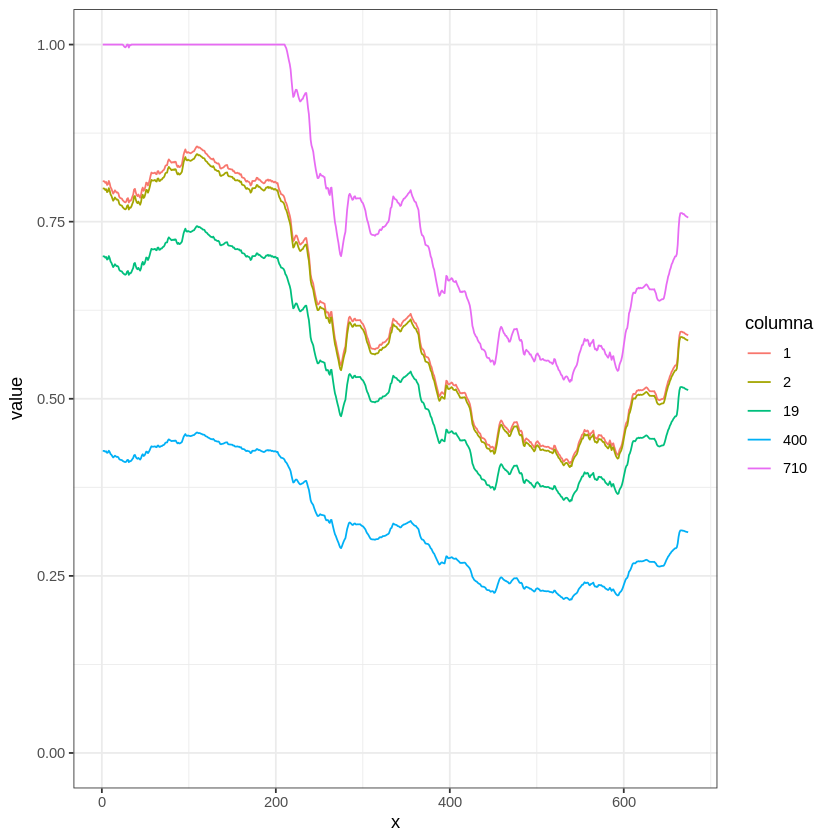

In [ ]:
cols <- c(1, 2, 19, 400, 710)

imag <- imagenes[[1]]
im_raster <- as.raster(imag)

ggplot() +
  annotation_raster(im_raster, xmin = 0, xmax = 720, ymin = 0, ymax = 674) +
  geom_vline(xintercept = cols, col = 2, alpha = .5) +
  xlim(0, 720) + ylim(0, 674) +
  coord_fixed()


imag[,cols] %>%
  as.data.table %>%
  setnames(new = as.character(cols)) %>%
  .[, x := .I] %>%
  melt("x", variable.name = "columna") %>%
  ggplot(aes(x = x, y = value, col = columna)) +
  geom_line() +
  ylim(c(0,1))


### Rango 3

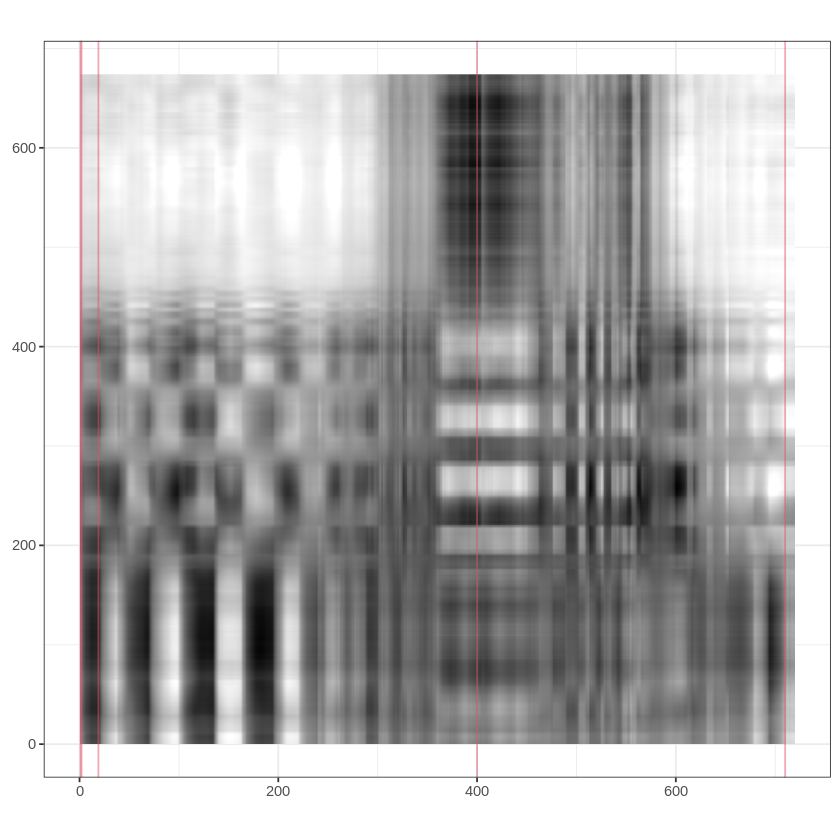

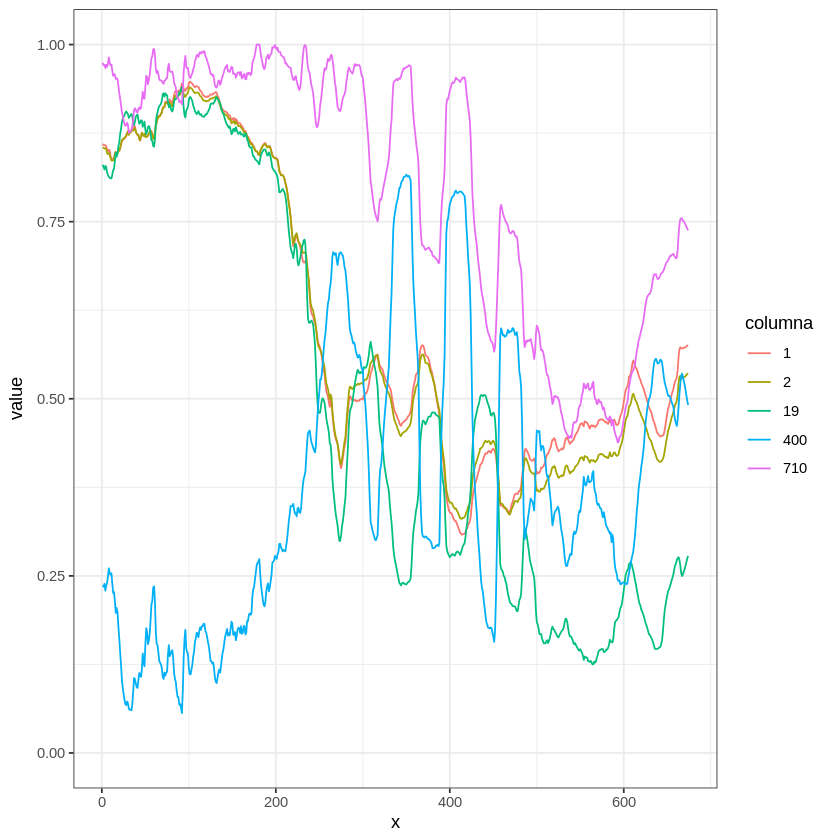

In [ ]:
imag <- imagenes[[3]]
im_raster <- as.raster(imag)

ggplot() +
  annotation_raster(im_raster, xmin = 0, xmax = 720, ymin = 0, ymax = 674) +
  geom_vline(xintercept = cols, col = 2, alpha = .5) +
  xlim(0, 720) + ylim(0, 674) +
  coord_fixed()


imag[,cols] %>%
  as.data.table %>%
  setnames(new = as.character(cols)) %>%
  .[, x := .I] %>%
  melt("x", variable.name = "columna") %>%
  ggplot(aes(x = x, y = value, col = columna)) +
  geom_line() +
  ylim(c(0,1))


### Rango 200

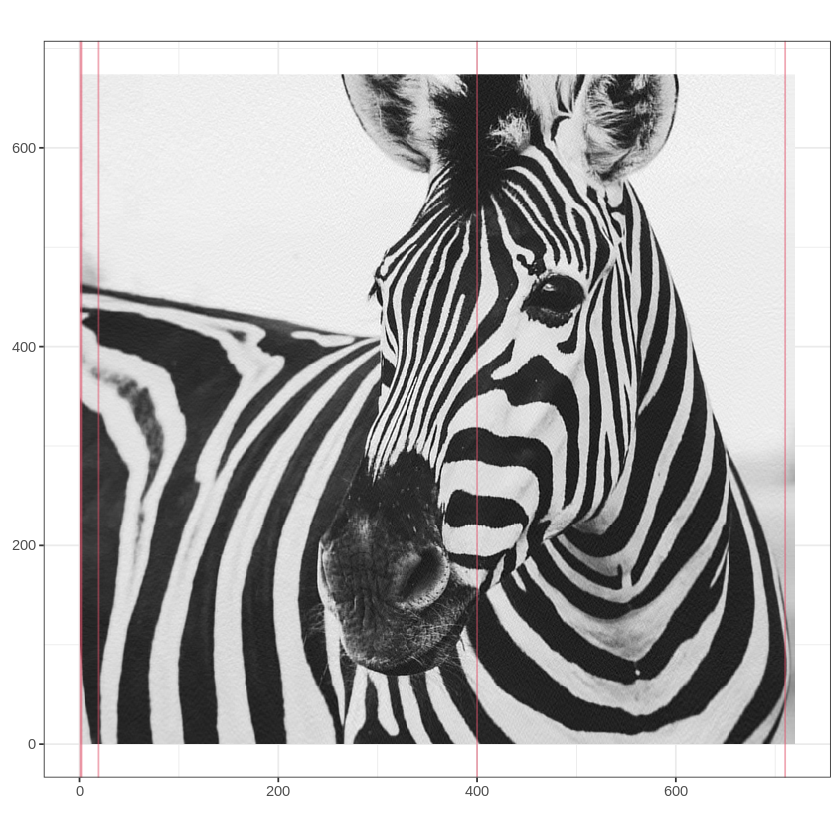

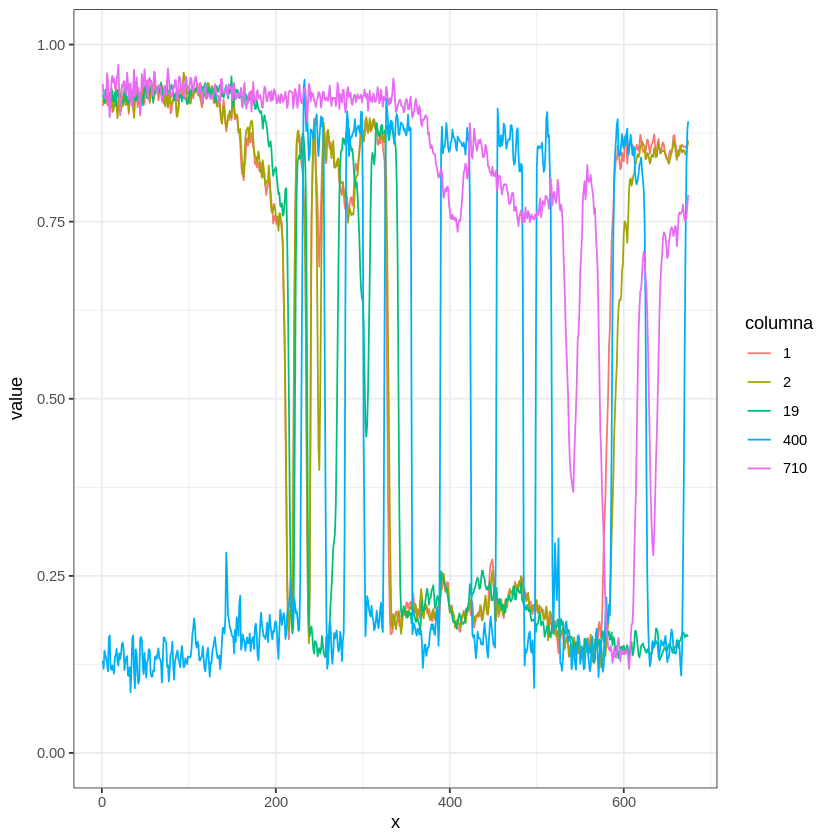

In [ ]:
imag <- imagenes[[9]]
im_raster <- as.raster(imag)

ggplot() +
  annotation_raster(im_raster, xmin = 0, xmax = 720, ymin = 0, ymax = 674) +
  geom_vline(xintercept = cols, col = 2, alpha = .5) +
  xlim(0, 720) + ylim(0, 674) +
  coord_fixed()


imag[,cols] %>%
  as.data.table %>%
  setnames(new = as.character(cols)) %>%
  .[, x := .I] %>%
  melt("x", variable.name = "columna") %>%
  ggplot(aes(x = x, y = value, col = columna)) +
  geom_line() +
  ylim(c(0,1))


